

# The Window Method Lags
### OPIM 5512 — Applied Data Science · Module4

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5512-notebooks/blob/main/Module4/TheWindowMethod_Lags.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# The Window Method
---------------------
**Dr. Dave Wanik - Operations and Information Management - University of Connecticut**

# Motivation

You have been given many files. Your job is to understand the impact of past weather and past generation on TODAY'S energy production. The `y` column is called `TOTAL` and it's present in both `traindf` and `testdf`.

I think the coolest column is 'PRD' (it's how much energy is 'produced' by telling big manusfacturers like paper mills or data centers to shut down for a few hours:

> *The ISO (Independent System Operator) monitors system conditions — if supply margins get thin (e.g., a hot summer afternoon or a cold snap), they can dispatch demand response resources just like power plants. Think of these as big industrial customers - they shut down and get paid NOT to consume power. It frees up supply.*








# Join all the energy data together (2126 rows)

In [ ]:
import pandas as pd
import os

# Define the directory containing the Excel files
directory_path = '/content/drive/MyDrive/Online Materials - Data Science /FinalProjects_F25'

# Get a list of all files in the directory and its subdirectories
excel_files = []
for root, _, files in os.walk(directory_path):
    for f in files:
        if f.endswith('.xlsx'):
            excel_files.append(os.path.join(root, f))

# Initialize an empty list to store DataFrames
df_list = []

# Read each Excel file and append the 'DAYGENBYFUEL' sheet to the list
for excel_file in excel_files:
    try:
        df = pd.read_excel(excel_file, sheet_name='DAYGENBYFUEL')
        df_list.append(df)
    except Exception as e:
        print(f"Error reading {excel_file}: {e}")

# Concatenate all DataFrames in the list
if df_list:
    energy_df = pd.concat(df_list, ignore_index=True)
    # Convert 'DATE' to datetime and set it as index
    energy_df['DATE'] = pd.to_datetime(energy_df['DATE'])
    energy_df.set_index('DATE', inplace=True)
    print("Successfully combined energy data:")
    display(energy_df.head())
else:
    print("No Excel files found or no data read.")

Successfully combined energy data:


,COAL,GAS,HYDRO,NUCLEAR,OIL,LANDFILL GAS,METHANE,REFUSE,SOLAR,STEAM,WIND,WOOD,OTHER,PRD,TOTAL
DATE,,,,,,,,,,,,,,,
2024-01-01,0.52,143001.686,32421.494,80679.820,4.003,1324.555,102.454,7534.500,6094.881,0,1598.842,4647.784,564.650,-0.098203,277975.090797
2024-01-02,17.12,151184.104,33293.692,80709.102,0.338,1310.940,92.596,7325.074,9487.691,0,4717.724,4660.427,828.647,-0.547897,293626.907103
2024-01-03,42.36,165047.508,30801.607,80728.718,104.270,1286.653,98.708,7360.587,6078.123,0,2370.850,5011.797,586.583,-0.019693,299517.744307
2024-01-04,118.84,141876.957,28588.978,80728.952,0.000,1272.456,109.081,7424.549,4976.516,0,8239.160,6218.011,468.836,0.000000,280022.336000
2024-01-05,17.17,145419.336,29596.409,80707.418,136.345,1275.857,107.875,7980.069,9549.611,0,13255.615,6745.573,712.909,0.000000,295504.187000


In [ ]:
energy_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2126 entries, 2024-01-01 to 2025-10-26
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   COAL          2126 non-null   float64
 1   GAS           2126 non-null   float64
 2   HYDRO         2126 non-null   float64
 3   NUCLEAR       2126 non-null   float64
 4   OIL           2126 non-null   float64
 5   LANDFILL GAS  2126 non-null   float64
 6   METHANE       2126 non-null   float64
 7   REFUSE        2126 non-null   float64
 8   SOLAR         2126 non-null   float64
 9   STEAM         2126 non-null   int64  
 10  WIND          2126 non-null   float64
 11  WOOD          2126 non-null   float64
 12  OTHER         2126 non-null   float64
 13  PRD           2126 non-null   float64
 14  TOTAL         2126 non-null   float64
dtypes: float64(14), int64(1)
memory usage: 265.8 KB


Setting the datetime as the index allows for easy joining.

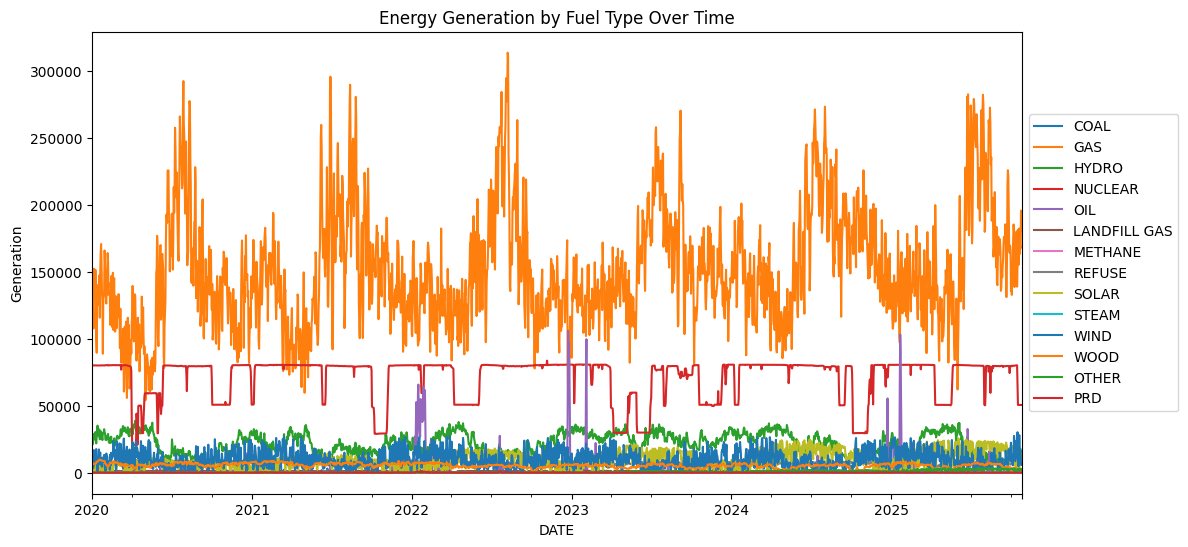

In [ ]:
import matplotlib.pyplot as plt

# Sort the DataFrame by index (DATE)
energy_df_sorted = energy_df.sort_index()

# Plot all columns except 'TOTAL'
ax = energy_df_sorted.drop('TOTAL', axis=1).plot(figsize=(12, 6))

# Put legend on the left
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.title('Energy Generation by Fuel Type Over Time')
plt.xlabel('DATE')
plt.ylabel('Generation')
plt.show()

**Figure 1:** time series plot of all columns.

# Concatenate the weather data

In [ ]:
weather_df = pd.read_csv('/content/drive/MyDrive/Online Materials - Data Science /FinalProjects_F25/Daily_GenerationByFuel/daily.txt')
print(weather_df.columns)
weather_df['day'] = pd.to_datetime(weather_df['day'])
weather_df.set_index('day', inplace=True)
weather_df.index.name = 'DATE' # Rename the index to match energy_df
print("Successfully loaded weather data:")
display(weather_df.head())

Index(['station', 'day', 'max_temp_f', 'min_temp_f', 'max_dewpoint_f',
       'min_dewpoint_f', 'precip_in', 'avg_wind_speed_kts', 'avg_wind_drct',
       'min_rh', 'avg_rh', 'min_feel', 'avg_feel', 'max_feel',
       'max_wind_speed_kts', 'max_wind_gust_kts', 'srad_mj'],
      dtype='object')
Successfully loaded weather data:


,station,max_temp_f,min_temp_f,max_dewpoint_f,min_dewpoint_f,precip_in,avg_wind_speed_kts,avg_wind_drct,min_rh,avg_rh,min_feel,avg_feel,max_feel,max_wind_speed_kts,max_wind_gust_kts,srad_mj
DATE,,,,,,,,,,,,,,,,
2020-01-01,BDL,39.0,32.0,30.0,21.9,0.0000,7.733889,266.43234,54.005466,65.49050,24.881613,28.401140,30.974932,18.248500,22.593382,NaN
2020-01-02,BDL,47.0,29.0,30.9,21.0,0.0000,7.125605,202.84612,45.473473,61.92596,22.713701,31.288322,40.921917,13.034643,17.379524,NaN
2020-01-03,BDL,47.0,37.0,39.9,32.0,0.0000,3.736598,180.81580,63.327920,76.16676,31.380903,40.076496,46.900000,10.427715,11.296691,NaN
2020-01-04,BDL,41.0,38.0,39.9,34.0,0.2200,3.910393,349.59344,85.689926,94.66637,29.922384,36.497646,39.900000,12.165668,16.510550,NaN
2020-01-05,BDL,39.0,25.0,33.1,17.1,0.0001,11.731179,314.79974,45.733845,61.13799,21.581379,25.550707,32.636097,25.200312,34.759050,NaN


# Weather Data Quality (2134 rows)

In [ ]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2134 entries, 2020-01-01 to 2025-11-03
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   station             2134 non-null   object 
 1   max_temp_f          2132 non-null   float64
 2   min_temp_f          2132 non-null   float64
 3   max_dewpoint_f      2134 non-null   float64
 4   min_dewpoint_f      2134 non-null   float64
 5   precip_in           2131 non-null   float64
 6   avg_wind_speed_kts  2133 non-null   float64
 7   avg_wind_drct       2133 non-null   float64
 8   min_rh              2134 non-null   float64
 9   avg_rh              2133 non-null   float64
 10  min_feel            2134 non-null   float64
 11  avg_feel            2133 non-null   float64
 12  max_feel            2134 non-null   float64
 13  max_wind_speed_kts  2134 non-null   float64
 14  max_wind_gust_kts   2128 non-null   float64
 15  srad_mj             0 non-null      f

# Join Datasets (2126 rows)

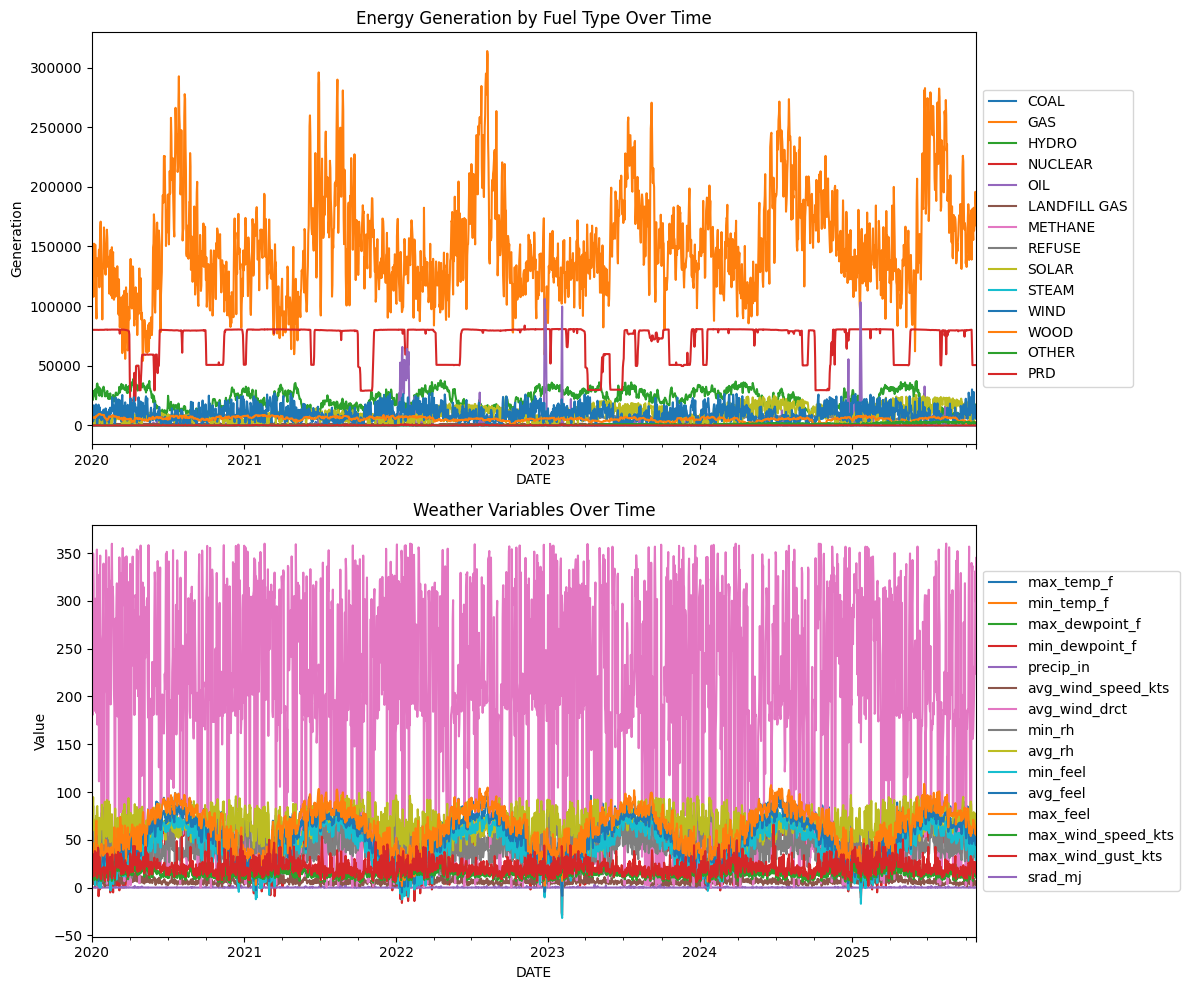

,COAL,GAS,HYDRO,NUCLEAR,OIL,LANDFILL GAS,METHANE,REFUSE,SOLAR,STEAM,...,avg_wind_speed_kts,avg_wind_drct,min_rh,avg_rh,min_feel,avg_feel,max_feel,max_wind_speed_kts,max_wind_gust_kts,srad_mj
DATE,,,,,,,,,,,,,,,,,,,,,
2020-01-01,95.90,102970.510,24703.740,80033.620,3.032,1403.857,115.840,8895.274,2786.022,0,...,7.733889,266.43234,54.005466,65.49050,24.881613,28.401140,30.974932,18.248500,22.593382,NaN
2020-01-02,23.64,122207.567,26767.720,80108.307,2885.127,1310.237,111.015,8177.457,3216.760,0,...,7.125605,202.84612,45.473473,61.92596,22.713701,31.288322,40.921917,13.034643,17.379524,NaN
2020-01-03,7.92,130630.104,21279.433,80151.023,3728.965,1303.274,104.657,7197.085,805.358,0,...,3.736598,180.81580,63.327920,76.16676,31.380903,40.076496,46.900000,10.427715,11.296691,NaN
2020-01-04,4.65,116483.404,24130.018,80154.281,0.000,1393.793,108.827,8359.937,338.083,0,...,3.910393,349.59344,85.689926,94.66637,29.922384,36.497646,39.900000,12.165668,16.510550,NaN
2020-01-05,50.63,107861.645,24674.196,80141.079,221.507,1356.650,108.903,8574.118,2581.808,0,...,11.731179,314.79974,45.733845,61.13799,21.581379,25.550707,32.636097,25.200312,34.759050,NaN


In [ ]:
# Join the two dataframes on their index (DATE)
combined_df = energy_df.join(weather_df, how='inner')

# Sort the combined dataframe by date
combined_df_sorted = combined_df.sort_index()

# Separate weather and energy columns (excluding 'TOTAL' and 'station')
energy_columns = energy_df.columns.drop('TOTAL')
weather_columns = weather_df.columns.drop('station') # Assuming 'station' is not needed for plotting

# Create a two-panel plot
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# Plot energy variables
combined_df_sorted[energy_columns].plot(ax=axes[0])
axes[0].set_title('Energy Generation by Fuel Type Over Time')
axes[0].set_ylabel('Generation')
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Plot weather variables
combined_df_sorted[weather_columns].plot(ax=axes[1])
axes[1].set_title('Weather Variables Over Time')
axes[1].set_xlabel('DATE')
axes[1].set_ylabel('Value')
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

display(combined_df_sorted.head())

**Figure 2:** time series plot of all columns in fuel dataset (top) and weather dataset (bottom).

You can see the data quality is VERY good. Just use zero imputation for missing values!

In [ ]:
combined_df_sorted.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2126 entries, 2020-01-01 to 2025-10-26
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   COAL                2126 non-null   float64
 1   GAS                 2126 non-null   float64
 2   HYDRO               2126 non-null   float64
 3   NUCLEAR             2126 non-null   float64
 4   OIL                 2126 non-null   float64
 5   LANDFILL GAS        2126 non-null   float64
 6   METHANE             2126 non-null   float64
 7   REFUSE              2126 non-null   float64
 8   SOLAR               2126 non-null   float64
 9   STEAM               2126 non-null   int64  
 10  WIND                2126 non-null   float64
 11  WOOD                2126 non-null   float64
 12  OTHER               2126 non-null   float64
 13  PRD                 2126 non-null   float64
 14  TOTAL               2126 non-null   float64
 15  station             2126 non-null   o

# Holdout Dataset: 2025 data

In [ ]:
train_df = combined_df_sorted[combined_df_sorted.index.year < 2025]
test_df = combined_df_sorted[combined_df_sorted.index.year >= 2025]

print("Shape of training data:", train_df.shape)
print("Shape of testing data:", test_df.shape)

Shape of training data: (1827, 31)
Shape of testing data: (299, 31)


In [ ]:
train_df.to_csv(directory_path + '/train_df.csv')
test_df.to_csv(directory_path + '/test_df.csv')

### 🔒 What You Can and Can’t Use Each Day
A reminder on data leakage!

When predicting **energy production on a given day (t)**:

- ✅ You **can use the weather for that same day (t)** — because weather is known or forecast in advance.  
  Example: If it’s **April 1, 2023**, you can use **April , 2023 weather** (like temperature, wind, sunlight).

- ✅ You **can use past energy and past weather** (from previous days).  
  Example: For **April 1, 2023**, you can use **March 31 energy** and **March 31 weather** (or earlier).  
  You can also use lagged or rolling features like “average temperature over the past 7 days.”

- ❌ You **cannot use today’s energy** (the thing you’re trying to predict) or any future data.  
  So no `TOTAL_t` or `TOTAL_t+1` in your predictors — that would be data leakage. You cannot use the individual energy generation for that same day, either.

---

**In short:**  
> “When predicting today’s energy, you can use today’s weather and anything from the past — but never today’s energy or anything from the future.”

Make sure your feature engineering follows that rule for both the **training data** (before Jan 1 2025) and the **test data** (all 2025 data).

---

**If you want a formula...:**


$
\widehat{E_t} = f(W_t,\, W_{t-1},\, W_{t-2},\, \ldots,\, E_{t-1},\, E_{t-2},\, \ldots)
$

Where:  
- $\widehat{E_t} $ = predicted energy on day *t*  
- $ W_t $ = today’s weather (known or forecast)  
- $ E_{t-1}, E_{t-2}, \ldots $ = past energy production  
- ❌ Do **not** use $ E_t $ or any $ W_{t+1+} $ values (future data)


# More Starter Code
This code is helpful to help you prevent dataleakage. Your dataset is 'day of' - so you need to be really careful with 'TOTAL' vs. all the other energy columns. If you include them, you are leaking!

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

traindf = pd.read_csv('/content/drive/MyDrive/Online Materials - Data Science /FinalProjects_F25/train_df.csv', index_col='DATE', parse_dates=True)
testdf = pd.read_csv('/content/drive/MyDrive/Online Materials - Data Science /FinalProjects_F25/test_df.csv', index_col='DATE', parse_dates=True)

## Be mindful of data leakage
You are predicting 'TOTAL' - the sum of all generation by type for the day.

If we are trying to predict today's total generation - we can't use the individual values of coal, gas, hydro etc.

In [ ]:
# Column names
production_columns = ['COAL', 'GAS', 'HYDRO', 'NUCLEAR', 'OIL', 'LANDFILL GAS', 'METHANE', 'REFUSE', 'SOLAR', 'STEAM', 'WIND', 'WOOD', 'OTHER', 'PRD']

# Check for train_df
traindf['Calculated_TOTAL'] = traindf[production_columns].sum(axis=1)
print("Train Data - Are 'TOTAL' and 'Calculated_TOTAL' equal?")
display(traindf[['TOTAL', 'Calculated_TOTAL']].head())


# Check for test_df
testdf['Calculated_TOTAL'] = testdf[production_columns].sum(axis=1)
print("\nTest Data - Are 'TOTAL' and 'Calculated_TOTAL' equal?")
display(testdf[['TOTAL', 'Calculated_TOTAL']].head())


Train Data - Are 'TOTAL' and 'Calculated_TOTAL' equal?


,TOTAL,Calculated_TOTAL
DATE,,
2020-01-01,239647.353000,239647.353000
2020-01-02,261355.739000,261355.739000
2020-01-03,261884.302000,261884.302000
2020-01-04,241411.092344,241411.092344
2020-01-05,249359.101067,249359.101067



Test Data - Are 'TOTAL' and 'Calculated_TOTAL' equal?


,TOTAL,Calculated_TOTAL
DATE,,
2025-01-01,265278.239178,265278.239178
2025-01-02,296560.122053,296560.122053
2025-01-03,272361.101098,272361.101098
2025-01-04,258342.620940,258342.620940
2025-01-05,261518.461367,261518.461367


## Shape of each dataframe

In [ ]:
traindf.head()

,COAL,GAS,HYDRO,NUCLEAR,OIL,LANDFILL GAS,METHANE,REFUSE,SOLAR,STEAM,...,avg_wind_drct,min_rh,avg_rh,min_feel,avg_feel,max_feel,max_wind_speed_kts,max_wind_gust_kts,srad_mj,Calculated_TOTAL
DATE,,,,,,,,,,,,,,,,,,,,,
2020-01-01,95.90,102970.510,24703.740,80033.620,3.032,1403.857,115.840,8895.274,2786.022,0,...,266.43234,54.005466,65.49050,24.881613,28.401140,30.974932,18.248500,22.593382,NaN,239647.353000
2020-01-02,23.64,122207.567,26767.720,80108.307,2885.127,1310.237,111.015,8177.457,3216.760,0,...,202.84612,45.473473,61.92596,22.713701,31.288322,40.921917,13.034643,17.379524,NaN,261355.739000
2020-01-03,7.92,130630.104,21279.433,80151.023,3728.965,1303.274,104.657,7197.085,805.358,0,...,180.81580,63.327920,76.16676,31.380903,40.076496,46.900000,10.427715,11.296691,NaN,261884.302000
2020-01-04,4.65,116483.404,24130.018,80154.281,0.000,1393.793,108.827,8359.937,338.083,0,...,349.59344,85.689926,94.66637,29.922384,36.497646,39.900000,12.165668,16.510550,NaN,241411.092344
2020-01-05,50.63,107861.645,24674.196,80141.079,221.507,1356.650,108.903,8574.118,2581.808,0,...,314.79974,45.733845,61.13799,21.581379,25.550707,32.636097,25.200312,34.759050,NaN,249359.101067


In [ ]:
print(traindf.shape)
print(testdf.shape)

(1827, 32)
(299, 32)


# Split into X and y
`y = TOTAL.` The other variables are repeating or have poor data quality.

In [ ]:
X_train = traindf.drop(columns=['TOTAL', 'srad_mj', 'station'], errors='ignore')
y_train = traindf['TOTAL']
X_test = testdf.drop(columns=['TOTAL', 'srad_mj', 'station'], errors='ignore')
y_test = testdf['TOTAL']

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1827, 29)
(299, 29)
(1827,)
(299,)


## Lagged features for modeling

To check your understanding of what lags are, look up! Try to match the values.

COAL = 4.65	... it's like the 4th row... which is the first row with good data quality once all the lags=3 are taken care of!

In [ ]:
def create_lag_features(df, lags=3):
    df_lagged = df.copy()
    for col in df.columns:
        for i in range(1, lags + 1):
            df_lagged[f'{col}_lag_{i}'] = df_lagged[col].shift(i)
    return df_lagged

X_train_lagged = create_lag_features(X_train)
X_test_lagged = create_lag_features(X_test)

# Drop rows with NaN values introduced by lagging
X_train_lagged = X_train_lagged.dropna()
y_train_lagged = y_train.loc[X_train_lagged.index]

X_test_lagged = X_test_lagged.dropna()
y_test_lagged = y_test.loc[X_test_lagged.index]


print("Shape of X_train_lagged:", X_train_lagged.shape)
print("Shape of X_test_lagged:", X_test_lagged.shape)

display(X_train_lagged.head())
display(X_test_lagged.head())

Shape of X_train_lagged: (1815, 116)
Shape of X_test_lagged: (288, 116)


,COAL,GAS,HYDRO,NUCLEAR,OIL,LANDFILL GAS,METHANE,REFUSE,SOLAR,STEAM,...,max_feel_lag_3,max_wind_speed_kts_lag_1,max_wind_speed_kts_lag_2,max_wind_speed_kts_lag_3,max_wind_gust_kts_lag_1,max_wind_gust_kts_lag_2,max_wind_gust_kts_lag_3,Calculated_TOTAL_lag_1,Calculated_TOTAL_lag_2,Calculated_TOTAL_lag_3
DATE,,,,,,,,,,,,,,,,,,,,,
2020-01-04,4.65,116483.404,24130.018,80154.281,0.000,1393.793,108.827,8359.937,338.083,0,...,30.974932,10.427715,13.034643,18.248500,11.296691,17.379524,22.593382,261884.302000,261355.739000,239647.353000
2020-01-05,50.63,107861.645,24674.196,80141.079,221.507,1356.650,108.903,8574.118,2581.808,0,...,40.921917,12.165668,10.427715,13.034643,16.510550,11.296691,17.379524,241411.092344,261884.302000,261355.739000
2020-01-06,75.45,152334.496,29047.983,80121.702,139.740,1302.520,110.002,8295.587,1133.280,0,...,46.900000,25.200312,12.165668,10.427715,34.759050,16.510550,11.296691,249359.101067,241411.092344,261884.302000
2020-01-07,179.29,139976.576,26030.209,80131.602,3987.187,1307.392,111.769,7698.627,2999.724,0,...,39.900000,12.165668,25.200312,12.165668,14.772596,34.759050,16.510550,284888.018468,249359.101067,241411.092344
2020-01-08,2.11,139266.704,27345.223,80116.228,447.365,1289.124,112.141,7420.552,2651.311,0,...,32.636097,7.820786,12.165668,25.200312,12.165668,14.772596,34.759050,276065.543335,284888.018468,249359.101067


,COAL,GAS,HYDRO,NUCLEAR,OIL,LANDFILL GAS,METHANE,REFUSE,SOLAR,STEAM,...,max_feel_lag_3,max_wind_speed_kts_lag_1,max_wind_speed_kts_lag_2,max_wind_speed_kts_lag_3,max_wind_gust_kts_lag_1,max_wind_gust_kts_lag_2,max_wind_gust_kts_lag_3,Calculated_TOTAL_lag_1,Calculated_TOTAL_lag_2,Calculated_TOTAL_lag_3
DATE,,,,,,,,,,,,,,,,,,,,,
2025-01-04,787.426,107615.149,27415.912,80559.793,38.136,920.284,54.886,6899.088,9080.812,0,...,53.000000,19.986454,26.069286,21.724405,26.938263,38.234955,33.890070,272361.101098,296560.122053,265278.239178
2025-01-05,246.480,110279.547,24187.325,80579.759,1094.555,1029.046,52.789,7665.589,6460.372,0,...,38.223020,26.069286,19.986454,26.069286,39.103930,26.938263,38.234955,258342.620940,272361.101098,296560.122053
2025-01-06,205.860,135619.182,24121.463,80588.392,14826.655,1080.685,52.577,7815.582,4604.560,0,...,32.447464,19.986454,26.069286,19.986454,28.676216,39.103930,26.938263,261518.461367,258342.620940,272361.101098
2025-01-07,1460.617,147474.366,22406.975,80607.867,22508.255,1119.274,54.170,7445.257,7900.256,0,...,24.325960,17.379524,19.986454,26.069286,26.938263,28.676216,39.103930,297219.283674,261518.461367,258342.620940
2025-01-08,5811.289,137501.419,21199.086,80602.196,24665.836,1112.307,59.341,7740.146,10769.937,0,...,25.530327,28.676216,17.379524,19.986454,39.972908,26.938263,28.676216,324720.316481,297219.283674,261518.461367


In [ ]:
29*4 # current time + 3 daily lags * 29 columns  = 116

116

# Beware of current day energy!
As you know, we will always know today's weather but not individual generation for today... so drop those columns!

In [ ]:
production_columns_to_drop = ['COAL', 'GAS', 'HYDRO', 'NUCLEAR', 'OIL', 'LANDFILL GAS', 'METHANE', 'REF', 'REFUSE', 'SOLAR', 'STEAM', 'WIND', 'WOOD', 'OTHER', 'PRD', 'TOTAL', 'Calculated_TOTAL']

print("Shape of X_train before dropping production columns:", X_train_lagged.shape)
print("Shape of X_test before dropping production columns:", X_test_lagged.shape)

X_train_lagged = X_train_lagged.drop(columns=production_columns_to_drop, errors='ignore')
X_test_lagged = X_test_lagged.drop(columns=production_columns_to_drop, errors='ignore')

print("Shape of X_train after dropping production columns:", X_train_lagged.shape)
print("Shape of X_test after dropping production columns:", X_test_lagged.shape)

display(X_train_lagged.head())
display(X_test_lagged.head())

Shape of X_train before dropping production columns: (1815, 116)
Shape of X_test before dropping production columns: (288, 116)
Shape of X_train after dropping production columns: (1815, 101)
Shape of X_test after dropping production columns: (288, 101)


,max_temp_f,min_temp_f,max_dewpoint_f,min_dewpoint_f,precip_in,avg_wind_speed_kts,avg_wind_drct,min_rh,avg_rh,min_feel,...,max_feel_lag_3,max_wind_speed_kts_lag_1,max_wind_speed_kts_lag_2,max_wind_speed_kts_lag_3,max_wind_gust_kts_lag_1,max_wind_gust_kts_lag_2,max_wind_gust_kts_lag_3,Calculated_TOTAL_lag_1,Calculated_TOTAL_lag_2,Calculated_TOTAL_lag_3
DATE,,,,,,,,,,,,,,,,,,,,,
2020-01-04,41.0,38.0,39.9,34.0,0.2200,3.910393,349.59344,85.689926,94.666370,29.922384,...,30.974932,10.427715,13.034643,18.248500,11.296691,17.379524,22.593382,261884.302000,261355.739000,239647.353000
2020-01-05,39.0,25.0,33.1,17.1,0.0001,11.731179,314.79974,45.733845,61.137990,21.581379,...,40.921917,12.165668,10.427715,13.034643,16.510550,11.296691,17.379524,241411.092344,261884.302000,261355.739000
2020-01-06,40.0,27.0,30.2,19.0,0.0100,4.866267,184.92734,54.765980,70.845420,20.457241,...,46.900000,25.200312,12.165668,10.427715,34.759050,16.510550,11.296691,249359.101067,241411.092344,261884.302000
2020-01-07,42.0,24.0,23.0,19.0,0.0001,3.997291,195.97495,42.615110,59.818893,16.246609,...,39.900000,12.165668,25.200312,12.165668,14.772596,34.759050,16.510550,284888.018468,249359.101067,241411.092344
2020-01-08,42.0,24.0,26.1,3.9,0.0001,9.211148,287.02377,38.932404,61.784150,9.725766,...,32.636097,7.820786,12.165668,25.200312,12.165668,14.772596,34.759050,276065.543335,284888.018468,249359.101067


,max_temp_f,min_temp_f,max_dewpoint_f,min_dewpoint_f,precip_in,avg_wind_speed_kts,avg_wind_drct,min_rh,avg_rh,min_feel,...,max_feel_lag_3,max_wind_speed_kts_lag_1,max_wind_speed_kts_lag_2,max_wind_speed_kts_lag_3,max_wind_gust_kts_lag_1,max_wind_gust_kts_lag_2,max_wind_gust_kts_lag_3,Calculated_TOTAL_lag_1,Calculated_TOTAL_lag_2,Calculated_TOTAL_lag_3
DATE,,,,,,,,,,,,,,,,,,,,,
2025-01-04,34.0,24.0,18.0,11.0,0.0,11.470487,296.48682,37.928030,50.040134,13.901231,...,53.000000,19.986454,26.069286,21.724405,26.938263,38.234955,33.890070,272361.101098,296560.122053,265278.239178
2025-01-05,35.0,29.0,19.0,13.0,0.0,11.904975,282.75528,43.300385,50.964237,19.114859,...,38.223020,26.069286,19.986454,26.069286,39.103930,26.938263,38.234955,258342.620940,272361.101098,296560.122053
2025-01-06,30.0,19.0,18.0,5.0,0.0,6.778015,328.07895,50.716770,59.907540,6.037944,...,32.447464,19.986454,26.069286,19.986454,28.676216,39.103930,26.938263,261518.461367,258342.620940,272361.101098
2025-01-07,30.0,17.0,14.0,5.0,0.0,13.729825,319.36210,40.582714,53.000230,4.183437,...,24.325960,17.379524,19.986454,26.069286,26.938263,28.676216,39.103930,297219.283674,261518.461367,258342.620940
2025-01-08,30.0,21.0,12.0,5.0,0.0,17.466423,308.69986,36.890667,47.502266,6.584871,...,25.530327,28.676216,17.379524,19.986454,39.972908,26.938263,28.676216,324720.316481,297219.283674,261518.461367


In [ ]:
print(X_train_lagged.columns)

Index(['max_temp_f', 'min_temp_f', 'max_dewpoint_f', 'min_dewpoint_f',
       'precip_in', 'avg_wind_speed_kts', 'avg_wind_drct', 'min_rh', 'avg_rh',
       'min_feel',
       ...
       'max_feel_lag_3', 'max_wind_speed_kts_lag_1',
       'max_wind_speed_kts_lag_2', 'max_wind_speed_kts_lag_3',
       'max_wind_gust_kts_lag_1', 'max_wind_gust_kts_lag_2',
       'max_wind_gust_kts_lag_3', 'Calculated_TOTAL_lag_1',
       'Calculated_TOTAL_lag_2', 'Calculated_TOTAL_lag_3'],
      dtype='object', length=101)


In [ ]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(X_train_lagged.columns)

Index(['max_temp_f', 'min_temp_f', 'max_dewpoint_f', 'min_dewpoint_f',
       'precip_in', 'avg_wind_speed_kts', 'avg_wind_drct', 'min_rh', 'avg_rh',
       'min_feel',
       ...
       'max_feel_lag_3', 'max_wind_speed_kts_lag_1',
       'max_wind_speed_kts_lag_2', 'max_wind_speed_kts_lag_3',
       'max_wind_gust_kts_lag_1', 'max_wind_gust_kts_lag_2',
       'max_wind_gust_kts_lag_3', 'Calculated_TOTAL_lag_1',
       'Calculated_TOTAL_lag_2', 'Calculated_TOTAL_lag_3'],
      dtype='object', length=101)


In [ ]:
model_lagged = DecisionTreeRegressor(min_samples_leaf=20)
model_lagged.fit(X_train_lagged, y_train_lagged)
trainpreds_lagged = model_lagged.predict(X_train_lagged)
testpreds_lagged = model_lagged.predict(X_test_lagged)

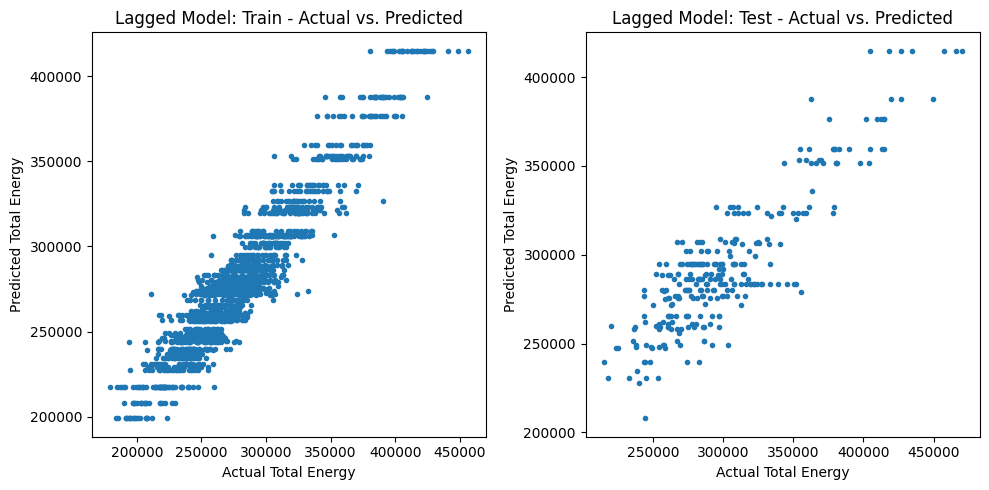

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(y_train_lagged, trainpreds_lagged, '.')
plt.title('Lagged Model: Train - Actual vs. Predicted')
plt.xlabel('Actual Total Energy')
plt.ylabel('Predicted Total Energy')
plt.subplot(1, 2, 2)
plt.plot(y_test_lagged, testpreds_lagged, '.')
plt.title('Lagged Model: Test - Actual vs. Predicted')
plt.xlabel('Actual Total Energy')
plt.ylabel('Predicted Total Energy')
plt.tight_layout()
plt.show()

**Figure 3:** two panel plot of actual vs predicted for DTR model.

This is a solid model... but can you do better?! Don't forget solid EDA and model interpretability. Good luck.

# Interpretability/xAI

In [ ]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the test set
result = permutation_importance(model_lagged, X_test_lagged, y_test_lagged, n_repeats=10, random_state=42, n_jobs=-1)

# Organize results into a DataFrame
perm_importance_df = pd.DataFrame({
    'feature': X_test_lagged.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
})

# Sort by importance_mean in descending order
perm_importance_df = perm_importance_df.sort_values(by='importance_mean', ascending=False)

# Display the top 10 features
print("Top 10 Permutation Importances:")
display(perm_importance_df.head(10))

Top 10 Permutation Importances:


,feature,importance_mean,importance_std
98,Calculated_TOTAL_lag_1,0.541598,0.057924
10,avg_feel,0.359910,0.030885
1,min_temp_f,0.034654,0.009585
11,max_feel,0.014604,0.005256
39,SOLAR_lag_2,0.006691,0.002711
54,PRD_lag_2,0.004182,0.001280
47,WOOD_lag_1,0.004036,0.001495
13,max_wind_gust_kts,0.003645,0.001796
12,max_wind_speed_kts,0.002025,0.001220
59,min_temp_f_lag_1,0.001354,0.000909


Generating partial dependence plots for the top 3 features: ['Calculated_TOTAL_lag_1', 'avg_feel', 'min_temp_f']


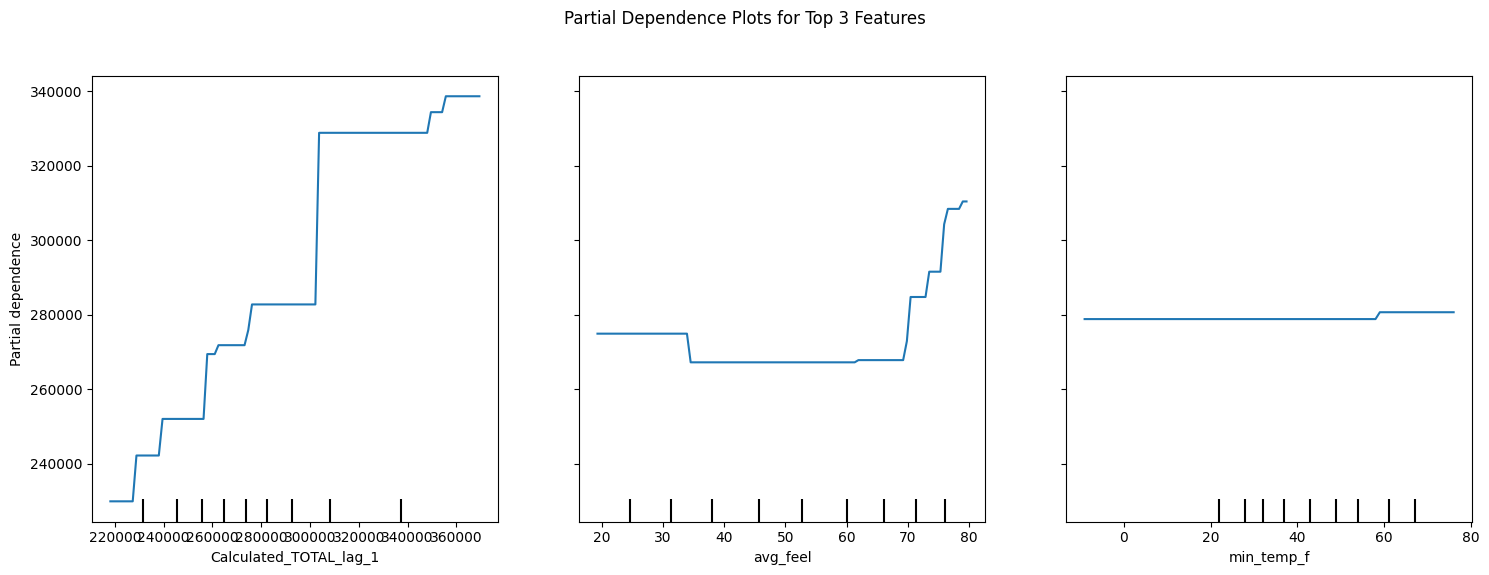

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# Get the top 3 features from the permutation importance DataFrame
top_3_features = perm_importance_df['feature'].head(3).tolist()

print(f"Generating partial dependence plots for the top 3 features: {top_3_features}")

# Create partial dependence plots
fig, ax = plt.subplots(figsize=(15, 6))
PartialDependenceDisplay.from_estimator(
    model_lagged,
    X_train_lagged,
    top_3_features,
    ax=ax,
    feature_names=X_train_lagged.columns.tolist() # Pass all feature names for proper display
)

fig.suptitle('Partial Dependence Plots for Top 3 Features')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

**Figure 4:** Partial dependence plots for top important features.

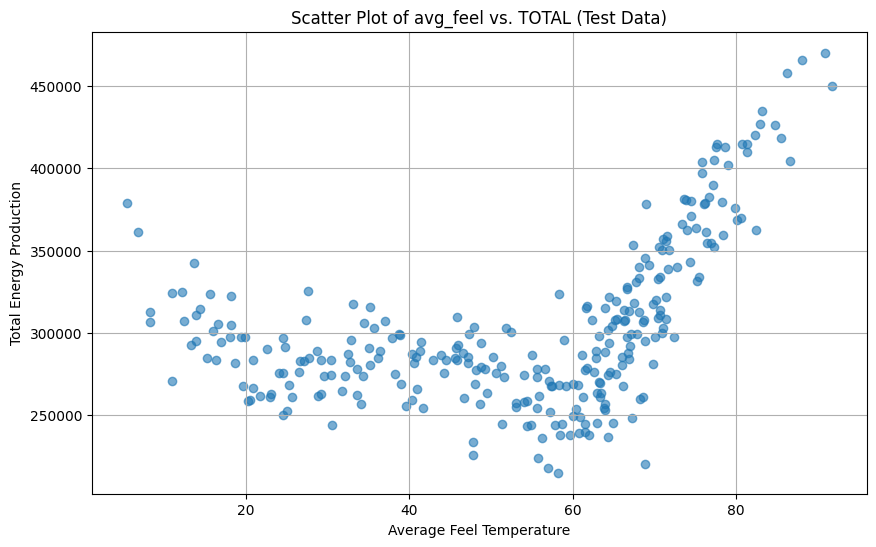

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test_lagged['avg_feel'], y_test_lagged, alpha=0.6)
plt.title('Scatter Plot of avg_feel vs. TOTAL (Test Data)')
plt.xlabel('Average Feel Temperature')
plt.ylabel('Total Energy Production')
plt.grid(True)
plt.show()

**Figure 5:** scatterplot showing relationship between total energy and avg temp feel.